============================================================
Session 0: The PyTorch Training Loop
============================================================
Target audience: ML Engineers familiar with data work,
possibly new to PyTorch.

What you will build: a text classifier that predicts whether
a movie review is positive or negative (IMDb dataset).

Why text and not MNIST: you work with text data. A text
classification task is closer to what you will see in
Sessions 5 and 6 (LoRA fine-tuning, HPO).

What you will learn:
  1. The five steps of every training loop
  2. What gradients are and why they matter
  3. What the optimizer does and why it holds memory
  4. What the dataloader does
  5. Mixed precision training
  6. Gradient accumulation

Time: ~60 minutes to read, run, and complete the exercises.


## PART 0: Installation and imports

Run this cell first. If you are on Google Colab, everything
is already installed. If local, run:
  pip install torch datasets scikit-learn 

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

# Check if a GPU is available.
# If you are on Colab: Runtime > Change runtime type > GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# If this prints 'cpu', the notebook still works but will be slower.
# More importantly: you will not see memory numbers that matter.
# The concepts are identical on CPU and GPU.

Using device: cpu



## PART 1: The data

We use the IMDb dataset: 50,000 movie reviews labeled
positive (1) or negative (0).

We intentionally use TF-IDF features instead of a pretrained
tokenizer. Reason: we want the focus on the training loop,
not on tokenization. Sessions 5+ will use real tokenizers.

In [2]:
print("Loading IMDb dataset...")
# dataset = load_dataset("imdb")
dataset = load_dataset("stanfordnlp/imdb", trust_remote_code=True)

# Take a look at the raw data
print("\nOne example from the training set:")
print("Label:", dataset["train"][0]["label"],
      "(1=positive, 0=negative)")
print("Text preview:", dataset["train"][0]["text"][:200])

# Extract texts and labels
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]
test_texts  = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

print(f"\nTraining examples: {len(train_texts)}")
print(f"Test examples:     {len(test_texts)}")

Loading IMDb dataset...

One example from the training set:
Label: 0 (1=positive, 0=negative)
Text preview: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

Training examples: 25000
Test examples:     25000


In [3]:
pd.array(dataset["test"]['label']).value_counts() #.unique()

0    12500
1    12500
Name: count, dtype: Int64

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [5]:
print(dataset["test"]['text'][:3])
print(dataset["test"]['label'][:3])


['I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it\'s rubbish as they hav

In [6]:
print(dataset["train"]['text'][:1])
print(dataset["train"]['label'][:6])


['I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, e

In [7]:
print(dataset["unsupervised"]['text'][:3])
print(dataset["unsupervised"]['label'][:3])


['This is just a precious little diamond. The play, the script are excellent. I cant compare this movie with anything else, maybe except the movie "Leon" wonderfully played by Jean Reno and Natalie Portman. But... What can I say about this one? This is the best movie Anne Parillaud has ever played in (See please "Frankie Starlight", she\'s speaking English there) to see what I mean. The story of young punk girl Nikita, taken into the depraved world of the secret government forces has been exceptionally over used by Americans. Never mind the "Point of no return" and especially the "La femme Nikita" TV series. They cannot compare the original believe me! Trash these videos. Buy this one, do not rent it, BUY it. BTW beware of the subtitles of the LA company which "translate" the US release. What a disgrace! If you cant understand French, get a dubbed version. But you\'ll regret later :)', 'When I say this is my favourite film of all time, that comment is not to be taken lightly. I probabl


PART 1b: Convert text to numbers with TF-IDF

Neural networks cannot read strings. We need to convert
each review into a fixed-size vector of numbers.

TF-IDF gives each review a vector of length 10,000 where
each dimension represents how important a word is in that
review relative to the whole dataset.

This is NOT how modern LLMs handle text (they use learned
embeddings), but it lets us focus on the training loop.


In [6]:

print("Fitting TF-IDF vectorizer on training data...")
vectorizer = TfidfVectorizer(max_features=10_000, sublinear_tf=True)

# fit_transform: learn vocabulary from training data, then
# transform training data. Never fit on test data — that
# would be data leakage.
X_train = vectorizer.fit_transform(train_texts).toarray().astype(np.float32)
X_test  = vectorizer.transform(test_texts).toarray().astype(np.float32)

y_train = np.array(train_labels, dtype=np.float32)
y_test  = np.array(test_labels,  dtype=np.float32)

print(f"\nShape of one training example: {X_train[0].shape}")
print(f"Each review is now a vector of {X_train.shape[1]} numbers")
print(f"Label for first review: {y_train[0]} (1=positive)")

Fitting TF-IDF vectorizer on training data...

Shape of one training example: (10000,)
Each review is now a vector of 10000 numbers
Label for first review: 0.0 (1=positive)



## PART 2: The Dataset and DataLoader

PyTorch has a specific way of feeding data to a model.
You need two objects:

  Dataset  — holds your data, returns one example at a time
  DataLoader — batches examples, shuffles, prefetches

Why does this matter for LLM work?
A slow DataLoader starves your GPU. If data loading is
slower than the forward+backward pass, your GPU sits idle
waiting for the next batch. This is a real problem with
large text datasets. num_workers controls how many CPU
processes prefetch data in parallel while the GPU computes.

In [7]:
class ReviewDataset(Dataset):
    """
    A minimal PyTorch Dataset.
    Must implement __len__ and __getitem__.
    __getitem__ returns ONE example given an index.
    DataLoader calls this repeatedly to build batches.
    """
    def __init__(self, features, labels):
        # torch.tensor converts numpy arrays to PyTorch tensors.
        # Tensors are like numpy arrays but can live on GPU
        # and support automatic gradient computation.
        self.X = torch.tensor(features)
        self.y = torch.tensor(labels)

    def __len__(self):
        # DataLoader needs to know how many examples exist
        return len(self.y)

    def __getitem__(self, idx):
        # Return one (features, label) pair
        # DataLoader calls this for each index in a batch
        return self.X[idx], self.y[idx]

In [8]:
train_dataset = ReviewDataset(X_train, y_train)
test_dataset  = ReviewDataset(X_test,  y_test)

# DataLoader wraps the dataset and handles:
#   batch_size: how many examples per forward pass
#   shuffle:    randomize order each epoch (always True for training)
#   num_workers: CPU processes for prefetching (0 = main process only)
#   pin_memory: faster CPU→GPU transfer when using GPU
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,   # larger batch for evaluation (no gradients needed)
    shuffle=False,    # never shuffle test data
    num_workers=2,
    pin_memory=(device.type == "cuda")
)


In [9]:
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Batch size: 64")
print(f"Total training examples: {len(train_dataset)}")

# Peek at one batch
features_batch, labels_batch = next(iter(train_loader))
print(f"\nOne batch — features shape: {features_batch.shape}")
print(f"One batch — labels shape:   {labels_batch.shape}")
# features_batch is [64, 10000]: 64 reviews, each 10000 dimensions
# labels_batch is [64]: 64 labels (0 or 1)

Training batches per epoch: 391
Batch size: 64
Total training examples: 25000

One batch — features shape: torch.Size([64, 10000])
One batch — labels shape:   torch.Size([64])


## PART 3: The Model

We build a small MLP (Multi-Layer Perceptron).
Three linear layers with ReLU activations between them.

This is NOT a transformer. It is the simplest possible
neural network that works on this task. The training loop
we write here is IDENTICAL to the training loop used for
transformers, LLaMA, BERT, anything. The model changes,
the loop does not.

Architecture:
  Input: 10,000 (TF-IDF features)
  Hidden layer 1: 256 units
  Hidden layer 2: 64 units
  Output: 1 unit (probability of positive review)

In [10]:
class TextClassifier(nn.Module):
    """
    nn.Module is the base class for all PyTorch models.
    You must implement:
      __init__: define the layers
      forward:  define how data flows through the layers
    """
    def __init__(self, input_dim=10_000, hidden1=256, hidden2=64):
        super().__init__()

        # nn.Sequential: a container that runs layers in order
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden1),  # matrix multiply + bias
            nn.ReLU(),                       # element-wise max(0, x)
            nn.Dropout(0.3),                 # randomly zero 30% of values during training
                                             # this reduces overfitting
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden2, 1)            # output: single logit
            # No sigmoid here — BCEWithLogitsLoss applies it internally
            # and is numerically more stable than sigmoid + BCELoss
        )

    def forward(self, x):
        # This method is called when you do model(input)
        # PyTorch traces this call to build the computation graph
        # which is used later for the backward pass
        return self.network(x).squeeze(1)  # [batch, 1] -> [batch]

In [12]:
# Instantiate and move to GPU (or CPU if no GPU)
model = TextClassifier().to(device)
print("Device:", device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
# For reference: LLaMA-3 8B has 8,000,000,000 parameters
# Our model has ~2.6M. The training loop is the same.

# Memory used by parameters alone (fp32 = 4 bytes per parameter)
param_memory_mb = total_params * 4 / 1024 / 1024
print(f"Parameter memory (fp32): {param_memory_mb:.1f} MB")

Device: cpu
Total parameters:     2,576,769
Trainable parameters: 2,576,769
Parameter memory (fp32): 9.8 MB


## PART 4: Loss function and Optimizer

Loss function: measures how wrong the model's predictions are.
Returns a single number. Training tries to minimize this number.

BCEWithLogitsLoss is for binary classification.
For multi-class: CrossEntropyLoss.
For regression: MSELoss.

In [ ]:
criterion = nn.BCEWithLogitsLoss()

# Optimizer: uses gradients to update weights.
# Adam is standard for almost all deep learning.
# lr (learning rate): how large each update step is.
#   Too large: training diverges (loss explodes)
#   Too small: training is very slow
#   Typical range: 1e-5 to 1e-2. Default 1e-3 is a safe start.

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------------------------------------------
# SIDEBAR: Why optimizer state matters for memory
# -----------------------------------------------------------------
# SGD:  stores nothing extra. Just subtracts lr * gradient.
#       w_new = w - lr * gradient
#
# Adam: stores TWO extra numbers per parameter:
#   m = running average of gradients (first moment)
#   v = running average of squared gradients (second moment)
#   w_new = w - lr * m / (sqrt(v) + epsilon)
#
# This means Adam needs 3x the memory of weights alone:
#   weights (fp32): 4 bytes/param
#   m (fp32):       4 bytes/param
#   v (fp32):       4 bytes/param
#   Total:          12 bytes/param
#
# For a 7B model: 7e9 * 12 = 84 GB just for weights + optimizer
# This is why ZeRO and FSDP exist (covered in Session 3).
# This is why QLoRA only trains a small subset of parameters
# (covered in Session 5).

adam_memory_mb = total_params * 12 / 1024 / 1024
print(f"Memory for weights + Adam state (fp32): {adam_memory_mb:.1f} MB")
print(f"For a 7B model this would be: {7e9 * 12 / 1024**3:.0f} GB")

Memory for weights + Adam state (fp32): 29.5 MB
For a 7B model this would be: 78 GB


: 


## PART 5: THE TRAINING LOOP

This is the core of the notebook. Read every comment.
The five steps are labeled explicitly.
This exact structure appears in every training script
for every model, including LLaMA, BERT, Stable Diffusion.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Runs one full pass through the training data.
    Returns average loss and accuracy for this epoch.
    """
    model.train()
    # model.train() enables:
    #   - Dropout (randomly zeros activations)
    #   - BatchNorm running stats updates (not used here)
    # Always call model.train() before training,
    # model.eval() before evaluation.

    total_loss = 0.0
    correct = 0
    total = 0

    for features, labels in loader:
        # ----- STEP 0: Move data to the same device as the model -----
        # Data starts on CPU. Model is on GPU (if available).
        # They must be on the same device for computation.
        # .to(device) copies the tensor to the target device.
        # This is a common source of errors: "Expected all tensors
        # to be on the same device"
        features = features.to(device)
        labels   = labels.to(device)

        # ----- STEP 1: Zero the gradients -----
        # Gradients ACCUMULATE by default in PyTorch.
        # If you don't zero them, gradients from the previous
        # batch add to gradients from this batch.
        # This is usually a bug — but sometimes intentional
        # (see gradient accumulation section below).
        optimizer.zero_grad()

        # ----- STEP 2: Forward pass -----
        # Pass the input through the model.
        # PyTorch silently builds a computation graph as this runs.
        # Every operation is recorded so the backward pass
        # knows how to compute gradients.
        predictions = model(features)   # shape: [batch_size]

        # ----- STEP 3: Compute loss -----
        # Compare predictions to ground truth.
        # Returns a single scalar tensor.
        # This scalar has gradient tracking enabled —
        # the backward pass will start here.
        loss = criterion(predictions, labels)

        # ----- STEP 4: Backward pass -----
        # Computes dL/dw for every parameter w in the model.
        # PyTorch walks the computation graph backwards
        # (chain rule, applied automatically).
        # After this call, every parameter's .grad attribute
        # contains its gradient.
        loss.backward()

        # Optional but important: gradient clipping.
        # If gradients are very large, updates become huge
        # and training destabilizes. Clipping caps the
        # gradient norm at 1.0. Standard practice for LLMs.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # ----- STEP 5: Update weights -----
        # The optimizer reads each parameter's .grad
        # and updates the parameter values.
        # For Adam: uses moment estimates m and v.
        optimizer.step()
 
        # Track metrics
        total_loss += loss.item()  # .item() converts tensor to Python float
        predicted = (predictions > 0).float()  # logit > 0 means P(positive) > 0.5
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    """
    Runs one full pass through the evaluation data.
    No gradient computation — we are not updating weights.
    """
    model.eval()
    # model.eval() disables Dropout, freezes BatchNorm.
    # Call this before any evaluation or inference.

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        # torch.no_grad() tells PyTorch: do not build the
        # computation graph. This saves memory and speeds up
        # inference by ~2x. Always use this for evaluation
        # and production inference.
        for features, labels in loader:
            features = features.to(device)
            labels   = labels.to(device)

            predictions = model(features)
            loss = criterion(predictions, labels)

            total_loss += loss.item()
            predicted = (predictions > 0).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


## PART 6: Run training


In [19]:
N_EPOCHS = 5
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>8} | {'Val Acc':>7} | {'Time':>6}")
print("-" * 65)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(
        model, test_loader, criterion, device
    )

    elapsed = time.time() - t0

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.1%} | "
          f"{val_loss:>8.4f} | {val_acc:>6.1%} | {elapsed:>5.1f}s")

# Expected results after 5 epochs:
# Validation accuracy: ~88-90%
# This is a strong baseline for a bag-of-words model.
# A fine-tuned BERT achieves ~94-95% on the same task.

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |   Time
-----------------------------------------------------------------
    1 |     0.3389 |    85.1% |   0.2771 |  88.5% |   7.3s
    2 |     0.1708 |    93.9% |   0.3146 |  87.2% |   6.1s
    3 |     0.1080 |    96.2% |   0.3761 |  86.3% |   7.0s
    4 |     0.0592 |    98.0% |   0.5223 |  86.1% |   8.5s
    5 |     0.0244 |    99.2% |   0.6795 |  85.6% |   6.8s



## PART 7: Visualize training



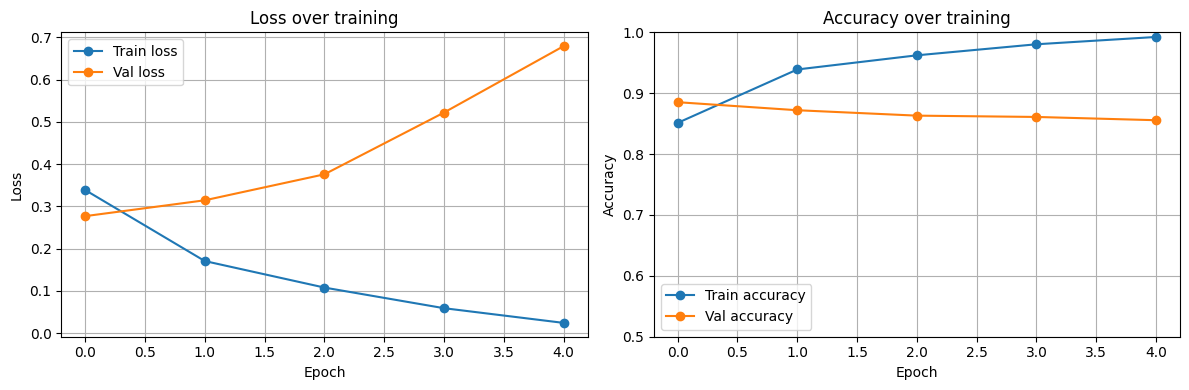

In [20]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train loss", marker="o")
ax1.plot(val_losses,   label="Val loss",   marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss over training")
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label="Train accuracy", marker="o")
ax2.plot(val_accs,   label="Val accuracy",   marker="o")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy over training")
ax2.set_ylim(0.5, 1.0)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# What to look for:
# - Both losses should decrease. If train loss decreases but
#   val loss increases: overfitting. The model memorizes
#   training data instead of learning general patterns.
# - If both losses barely move: learning rate is too small
#   or the model is too simple.
# - If loss jumps around wildly: learning rate is too large.


## PART 8: Look inside the gradients

After training, gradients reflect the last backward pass.
This section makes gradients visible and concrete.

In [ ]:
print("Gradients after the last backward pass:\n")
for name, param in model.named_parameters():
    if param.grad is not None:
        grad = param.grad
        print(f"  Layer: {name}")
        print(f"    Parameter shape: {param.shape}")
        print(f"    Gradient shape:  {grad.shape}")
        print(f"    Gradient mean:   {grad.mean().item():+.6f}")
        print(f"    Gradient std:    {grad.std().item():.6f}")
        print(f"    Gradient max abs:{grad.abs().max().item():.6f}")
        print()

# What you should observe:
# - Every parameter has a gradient of the same shape
# - Gradients are small numbers (typically 1e-4 to 1e-2)
# - The first layer gradients are often smaller than later
#   layers — this is the vanishing gradient problem that
#   residual connections in transformers solve

Gradients after the last backward pass:

  Layer: network.0.weight
    Parameter shape: torch.Size([256, 10000])
    Gradient shape:  torch.Size([256, 10000])
    Gradient mean:   -0.000001
    Gradient std:    0.000102
    Gradient max abs:0.009093

  Layer: network.0.bias
    Parameter shape: torch.Size([256])
    Gradient shape:  torch.Size([256])
    Gradient mean:   -0.001089
    Gradient std:    0.010754
    Gradient max abs:0.034370

  Layer: network.3.weight
    Parameter shape: torch.Size([64, 256])
    Gradient shape:  torch.Size([64, 256])
    Gradient mean:   -0.000001
    Gradient std:    0.000108
    Gradient max abs:0.001265

  Layer: network.3.bias
    Parameter shape: torch.Size([64])
    Gradient shape:  torch.Size([64])
    Gradient mean:   -0.000186
    Gradient std:    0.001734
    Gradient max abs:0.004386

  Layer: network.6.weight
    Parameter shape: torch.Size([1, 64])
    Gradient shape:  torch.Size([1, 64])
    Gradient mean:   +0.001020
    Gradient std:   

/tmp/ipykernel_2194682/2104226831.py:9: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1807.)
  print(f"    Gradient std:    {grad.std().item():.6f}")


## PART 9: What learning rate does

In [ ]:
# The learning rate is the most important hyperparameter.
# This section trains three identical models with different
# learning rates so you can see the effect directly.
# This sets up the intuition for Session 6 (HPO with Optuna).

def train_with_lr(lr, n_epochs=5):
    """Train a fresh model with a specific learning rate."""
    m = TextClassifier().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    losses = []
    for _ in range(n_epochs):
        loss, _ = train_one_epoch(m, train_loader, criterion, opt, device)
        losses.append(loss)
    return losses

Training with three learning rates (takes ~2 minutes)...
This is a manual version of what Optuna automates in Session 6.

  lr=1e-05...
  lr=0.001...
  lr=0.1...


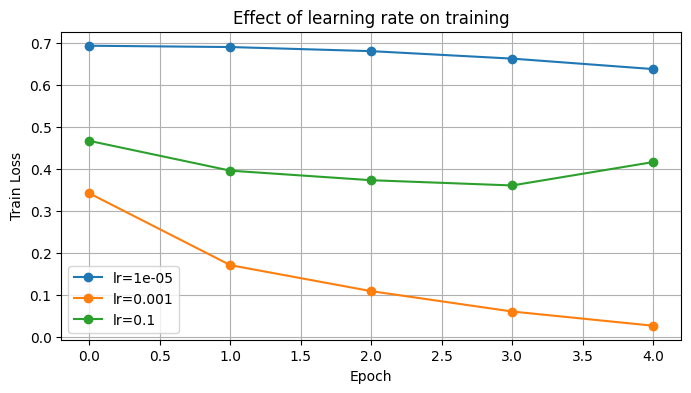

In [23]:

print("Training with three learning rates (takes ~2 minutes)...")
print("This is a manual version of what Optuna automates in Session 6.\n")

results = {}
for lr in [1e-5, 1e-3, 1e-1]:
    print(f"  lr={lr}...")
    results[lr] = train_with_lr(lr)

plt.figure(figsize=(8, 4))
for lr, losses in results.items():
    plt.plot(losses, marker="o", label=f"lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Effect of learning rate on training")
plt.legend()
plt.grid(True)
plt.show()

# Expected observations:
# lr=1e-5: loss decreases slowly, barely trained after 5 epochs
# lr=1e-3: loss decreases smoothly — this is a good learning rate
# lr=1e-1: loss may be erratic or high — too large, unstable updates
#
# The right learning rate is not obvious in advance.
# This is exactly why HPO tools like Optuna exist.


## PART 10: Mixed Precision Training

Modern LLM training uses fp16 or bf16 for most computations
and fp32 only for the optimizer update.

Why:
  fp32: 4 bytes per number, full precision
  fp16: 2 bytes per number, less range (can overflow)
  bf16: 2 bytes per number, same range as fp32, less precision

Benefit: ~2x less memory for activations and gradients.
Faster on Tensor Cores (specialized fp16 hardware in GPUs).

Risk: gradients can underflow to zero in fp16.
Solution: loss scaling — multiply loss by a large number
before backward pass to keep gradients large enough,
then divide by the same number before the optimizer step.
PyTorch automates this with GradScaler.

In [25]:


def train_one_epoch_mixed_precision(model, loader, criterion,
                                     optimizer, scaler, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for features, labels in loader:
        features = features.to(device)
        labels   = labels.to(device)

        optimizer.zero_grad()

        # torch.autocast: runs the forward pass in fp16/bf16
        # PyTorch automatically decides which operations are
        # safe in lower precision (linear layers, conv) and
        # which must stay in fp32 (softmax, loss computation)
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            predictions = model(features)
            loss = criterion(predictions, labels)

        # scaler.scale(loss): multiplies loss by scale factor
        # (e.g. 2^16 = 65536) before backward pass.
        # This prevents gradients from becoming zero in fp16.
        scaler.scale(loss).backward()

        # scaler.unscale_: divides gradients back by scale factor
        # before gradient clipping and optimizer step
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # scaler.step: if no inf/nan in gradients, calls optimizer.step()
        # if there ARE inf/nan (fp16 overflow), skips the step
        # and reduces the scale factor for next iteration
        scaler.step(optimizer)

        # scaler.update: adjusts scale factor for next iteration
        scaler.update()

        total_loss += loss.item()
        predicted = (predictions > 0).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


if device.type == "cuda":
    model_mp = TextClassifier().to(device)
    optimizer_mp = torch.optim.Adam(model_mp.parameters(), lr=1e-3)

    # GradScaler manages the loss scaling automatically
    scaler = torch.cuda.amp.GradScaler()

    print("Training with mixed precision (fp16)...")
    t0 = time.time()
    for epoch in range(1, 4):
        loss, acc = train_one_epoch_mixed_precision(
            model_mp, train_loader, criterion,
            optimizer_mp, scaler, device
        )
        print(f"  Epoch {epoch}: loss={loss:.4f}, acc={acc:.1%}")
    print(f"  Time: {time.time()-t0:.1f}s")

    # Compare to fp32 training time from Part 6
    # On a modern GPU you should see ~20-40% speedup
    # Memory savings are harder to see at this model size
    # but become critical at 7B+ parameters
else:
    print("Mixed precision requires a GPU. Skipping this section.")
    print("On Colab: Runtime > Change runtime type > GPU T4")
    print("Conceptually: fp32 -> fp16 halves activation memory.")
    print("For a 7B model this saves ~14 GB during training.")

Mixed precision requires a GPU. Skipping this section.
On Colab: Runtime > Change runtime type > GPU T4
Conceptually: fp32 -> fp16 halves activation memory.
For a 7B model this saves ~14 GB during training.



## PART 11: Gradient Accumulation

Problem: you want to train with batch size 256 but your
GPU only fits batch size 32.

Solution: run 8 forward+backward passes with batch size 32,
accumulate the gradients, then take one optimizer step.
Mathematically equivalent to one pass with batch size 256.

This is directly used in Session 5 (LoRA fine-tuning)
where large batch sizes improve training stability but
the model is too large to fit a large batch in GPU memory.

In [ ]:

def train_one_epoch_grad_accum(model, loader, criterion,
                                optimizer, device,
                                accumulation_steps=4):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    optimizer.zero_grad()  # zero once at the start

    for step, (features, labels) in enumerate(loader):
        features = features.to(device)
        labels   = labels.to(device)

        predictions = model(features)

        # Divide loss by accumulation steps so the accumulated
        # gradient is the average over all sub-batches,
        # not the sum. This keeps gradient magnitude consistent
        # regardless of accumulation steps.
        loss = criterion(predictions, labels) / accumulation_steps
        loss.backward()
        # Gradients are ADDED to existing .grad values here.
        # We do NOT call optimizer.zero_grad() inside the loop.

        if (step + 1) % accumulation_steps == 0:
            # Only update weights every N steps
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()   # NOW we clear gradients

        total_loss += loss.item() * accumulation_steps  # undo the division for logging
        predicted = (predictions > 0).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

In [ ]:
ACCUMULATION_STEPS = 4   # effective batch size = 64 * 4 = 256

model_ga = TextClassifier().to(device)
optimizer_ga = torch.optim.Adam(model_ga.parameters(), lr=1e-3)

print(f"Training with gradient accumulation (accumulation_steps={ACCUMULATION_STEPS})")
print(f"Effective batch size: 64 * {ACCUMULATION_STEPS} = {64 * ACCUMULATION_STEPS}\n")

for epoch in range(1, 4):
    loss, acc = train_one_epoch_grad_accum(
        model_ga, train_loader, criterion,
        optimizer_ga, device, ACCUMULATION_STEPS
    )
    print(f"  Epoch {epoch}: loss={loss:.4f}, acc={acc:.1%}")

# The accuracy should be similar to standard training.
# The difference: each optimizer step used 4x more data.
# Memory usage is the same as batch_size=64 (no change).
# This is the entire point: same memory, larger effective batch.

Training with gradient accumulation (accumulation_steps=4)
Effective batch size: 64 * 4 = 256

  Epoch 1: loss=0.4307, acc=81.4%
  Epoch 2: loss=0.1899, acc=92.8%
  Epoch 3: loss=0.1339, acc=95.4%


============================================================
PART 12: Memory accounting
============================================================
This section makes memory costs concrete.
Understanding memory is central to Sessions 3, 4, and 5.


In [ ]:

def count_memory(model, batch_size, input_dim, device):
    """Measure actual GPU memory used during training."""
    if device.type != "cuda":
        print("Memory measurement requires GPU. Showing estimates instead.")
        params = sum(p.numel() for p in model.parameters())
        print(f"\n  Parameters:          {params:>12,}")
        print(f"  Weights (fp32):      {params*4/1e6:>10.1f} MB")
        print(f"  Gradients (fp32):    {params*4/1e6:>10.1f} MB")
        print(f"  Adam state (fp32):   {params*8/1e6:>10.1f} MB")
        print(f"  Total training est.: {params*16/1e6:>10.1f} MB")
        print(f"\n  Rule of thumb: training needs ~16 bytes/parameter")
        print(f"  7B model: ~{7e9*16/1e9:.0f} GB minimum")
        return

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    before = torch.cuda.memory_allocated() / 1e6

    # Simulate one training step
    dummy_input  = torch.randn(batch_size, input_dim, device=device)
    dummy_labels = torch.randint(0, 2, (batch_size,),
                                  dtype=torch.float32, device=device)

    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    opt.zero_grad()
    out  = model(dummy_input)
    loss = nn.BCEWithLogitsLoss()(out, dummy_labels)
    loss.backward()
    opt.step()

    peak = torch.cuda.max_memory_allocated() / 1e6
    after = torch.cuda.memory_allocated() / 1e6

    params = sum(p.numel() for p in model.parameters())
    print(f"\n  Parameters:              {params:>10,}")
    print(f"  Memory before step:      {before:>10.1f} MB")
    print(f"  Peak memory during step: {peak:>10.1f} MB")
    print(f"  Memory after step:       {after:>10.1f} MB")
    print(f"  Activations + overhead:  {peak - after:>10.1f} MB")
    print(f"\n  Theoretical minimum (weights only, fp32): "
          f"{params*4/1e6:.1f} MB")
    print(f"  Actual peak is higher due to: gradients, "
          f"optimizer state, activations")


In [ ]:
print("Memory usage for our small model:")
count_memory(model, batch_size=64,
             input_dim=10_000, device=device)

print("\n\nFor reference — how this scales to real LLMs:")
print(f"  GPT-2  (117M params):  training needs ~{117e6*16/1e9:.1f} GB")
print(f"  LLaMA-3 7B:            training needs ~{7e9*16/1e9:.0f} GB")
print(f"  LLaMA-3 70B:           training needs ~{70e9*16/1e9:.0f} GB")
print(f"\n  This is why a single 80GB A100 cannot train a 70B model.")
print(f"  This is why ZeRO, FSDP, and LoRA exist.")

Memory usage for our small model:
Memory measurement requires GPU. Showing estimates instead.

  Parameters:             2,576,769
  Weights (fp32):            10.3 MB
  Gradients (fp32):          10.3 MB
  Adam state (fp32):         20.6 MB
  Total training est.:       41.2 MB

  Rule of thumb: training needs ~16 bytes/parameter
  7B model: ~112 GB minimum


For reference — how this scales to real LLMs:
  GPT-2  (117M params):  training needs ~1.9 GB
  LLaMA-3 7B:            training needs ~112 GB
  LLaMA-3 70B:           training needs ~1120 GB

  This is why a single 80GB A100 cannot train a 70B model.
  This is why ZeRO, FSDP, and LoRA exist.


## PART 13: Inference — how it differs from training

In [ ]:
# Inference is simpler and cheaper than training.
# No gradients, no optimizer state, smaller memory footprint.
# Understanding this difference motivates the entire inference
# optimization track (Sessions 2, 3, 4).

def run_inference(model, texts, vectorizer, device):
    """
    Production-style inference function.
    Note what is different from the training loop:
      - model.eval()
      - torch.no_grad()
      - No loss, no backward, no optimizer
      - Returns predictions, not gradients
    """
    model.eval()

    features = vectorizer.transform(texts).toarray().astype(np.float32)
    features_tensor = torch.tensor(features).to(device)

    with torch.no_grad():
        logits = model(features_tensor)
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities > 0.5).int()

    return predictions.cpu().numpy(), probabilities.cpu().numpy()


In [ ]:
# Test on new examples not in training data
new_reviews = [
    "This movie was absolutely brilliant. The acting was superb.",
    "Terrible waste of time. The plot made no sense whatsoever.",
    "It was okay, not great but not terrible either.",
]

preds, probs = run_inference(model, new_reviews, vectorizer, device)

print("Inference results on new reviews:\n")
for review, pred, prob in zip(new_reviews, preds, probs):
    sentiment = "POSITIVE" if pred == 1 else "NEGATIVE"
    print(f"  Review: {review[:60]}...")
    print(f"  Prediction: {sentiment} (confidence: {prob:.1%})\n")
    # print(f"  Prediction: {sentiment} (confidence: {prob[0]:.1%})\n")

# Memory comparison: training vs inference
params = sum(p.numel() for p in model.parameters())
print("Memory comparison:")
print(f"  Training  (fp32, Adam): ~{params*16/1e6:.1f} MB")
print(f"  Inference (fp32):       ~{params*4/1e6:.1f} MB  (weights only)")
print(f"  Inference (int8 quant): ~{params*1/1e6:.1f} MB  (4x compression)")
print(f"\n  For a 7B model:")
print(f"  Training:  ~{7e9*16/1e9:.0f} GB")
print(f"  Inference fp16: ~{7e9*2/1e9:.0f} GB")
print(f"  Inference int4: ~{7e9*0.5/1e9:.1f} GB  <- fits on consumer GPU")

Inference results on new reviews:

  Review: This movie was absolutely brilliant. The acting was superb....
  Prediction: POSITIVE (confidence: 100.0%)

  Review: Terrible waste of time. The plot made no sense whatsoever....
  Prediction: NEGATIVE (confidence: 0.0%)

  Review: It was okay, not great but not terrible either....
  Prediction: NEGATIVE (confidence: 0.3%)

Memory comparison:
  Training  (fp32, Adam): ~41.2 MB
  Inference (fp32):       ~10.3 MB  (weights only)
  Inference (int8 quant): ~2.6 MB  (4x compression)

  For a 7B model:
  Training:  ~112 GB
  Inference fp16: ~14 GB
  Inference int4: ~3.5 GB  <- fits on consumer GPU


---

## PART 14: Exercises


Complete these before Session 5.
Each exercise targets a specific concept from this notebook.

In [ ]:



print("""
EXERCISE 1 — Learning rate effect (5 min)
------------------------------------------
Change the learning rate in Part 6 to 1e-4 and rerun training.
Questions:
  a) Does the model converge to the same accuracy?
  b) How many epochs does it need to reach 85% validation accuracy?
  c) Why does a smaller learning rate need more epochs?


EXERCISE 2 — Gradient inspection (5 min)
------------------------------------------
After running Part 8, find the layer with the largest
average gradient magnitude. Find the layer with the smallest.
Questions:
  a) Which layer has the largest gradients?
  b) Does this match your expectation given the architecture?
  c) What would happen to training if all gradients were 1e-8?


EXERCISE 3 — Gradient accumulation (10 min)
------------------------------------------
In Part 11, change ACCUMULATION_STEPS to 1 (no accumulation)
and rerun. Compare the final accuracy to ACCUMULATION_STEPS=4.
Questions:
  a) Is there a difference in final accuracy?
  b) Is there a difference in training stability (loss curve)?
  c) When would you actually need gradient accumulation?
     Hint: think about model size and GPU memory.


EXERCISE 4 — no_grad memory (10 min)
------------------------------------------
Remove the torch.no_grad() context manager from the evaluate()
function in Part 5. Rerun training for one epoch.
Questions:
  a) Does accuracy change?
  b) Does training speed change? (Check the time column)
  c) If you were running inference on a 7B model in production
     and forgot torch.no_grad(), what would happen to memory?


EXERCISE 5 — Connect to LLM concepts (thinking exercise)
----------------------------------------------------------
You are deploying LLaMA-3 8B for a client. The client wants
to run it on a single A100 80GB GPU.

Using the memory formulas from Part 12:
  a) Does the model fit for inference in fp16?
  b) Does it fit for inference in int4?
  c) If the client also wants to fine-tune with LoRA
     (which adds ~1% extra parameters), does it fit
     for training in fp16 with Adam?
  d) What would you recommend?

Reference numbers:
  A100 80GB VRAM: 80 GB
  LLaMA-3 8B parameters: 8,000,000,000
  fp16: 2 bytes/param
  int4: 0.5 bytes/param
  Training (fp32 Adam): ~16 bytes/param
  LoRA adds ~1% parameters for fine-tuning
""")

In [ ]:
# ============================================================
# PART 15: Summary — what to remember
# ============================================================

print("""
SUMMARY: The Five Things to Remember
======================================

1. THE TRAINING LOOP HAS FIVE STEPS, ALWAYS IN THIS ORDER:
   zero_grad → forward → loss → backward → optimizer.step()
   This is true for a 2-layer MLP and for LLaMA-3 405B.

2. GRADIENTS ARE PER-WEIGHT SIGNALS.
   Each weight gets one number telling it which direction
   to move. The backward pass computes all of them at once
   using the chain rule. It costs ~2x the forward pass
   in both memory and compute.

3. ADAM STORES TWO EXTRA NUMBERS PER WEIGHT.
   Training memory ≈ 16 bytes/parameter (weights + gradients
   + Adam state, all fp32). Inference memory ≈ 2 bytes/param
   (weights only, fp16). This 8x difference is why deployment
   is cheaper than training.

4. MIXED PRECISION HALVES ACTIVATION MEMORY.
   Forward and backward in fp16, optimizer step in fp32.
   GradScaler handles the numerical stability automatically.
   Standard practice for any model > 1B parameters.

5. GRADIENT ACCUMULATION GIVES YOU LARGER EFFECTIVE BATCHES
   WITHOUT MORE MEMORY.
   Divide loss by N, run N backward passes without stepping,
   then step once. Mathematically equivalent to batch_size * N.
   Used in every LoRA fine-tuning recipe.

WHAT COMES NEXT:
  Session 3: Why GPU memory hierarchy makes all of this faster
             or slower depending on how you implement it.
  Session 4: How quantization reduces the 2 bytes/param
             inference cost to 0.5 bytes/param (int4).
  Session 5: How LoRA fine-tunes only 1% of parameters,
             making training fit in consumer GPU memory.
  Session 6: How Optuna automates the learning rate search
             you did manually in Part 9.
""")